# BGE + SPECTER + TF-IDF Ablation with External Human-Test Monitor

This notebook modifies the best-balanced classical ablation pipeline. The original human-labelled dataset is still used for model training and cross-validation. The new `Test_sampled_data.xlsx` file is used only as a held-out external monitoring/audit set.

The aim is to make the master-file predictions more trustworthy by reporting two layers of evidence:

1. internal cross-validation on the original human-labelled dataset; and
2. external audit performance on the newly human-verified test sample from the 10k master dataset.

The recommended best-balanced final strategy remains **BGE + SPECTER + TF-IDF**, while the notebook still evaluates all ablation variants.

In [ ]:
# ============================================================
# 0. Optional dependency setup
# ============================================================
# In Kaggle, turn Internet ON if transformers/sentence-transformers models are not cached.
# The notebook uses Hugging Face AutoModel/AutoTokenizer for BGE and SPECTER embeddings.
# Uncomment only if your environment is missing packages.

# !pip -q install transformers accelerate sentencepiece openpyxl

In [1]:
# ============================================================
# 1. Imports, paths, and global configuration
# ============================================================
import os, re, json, math, gc, time, random, zipfile, warnings, unicodedata, hashlib, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import scipy.sparse as sp

from scipy.special import expit, softmax
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------
# File paths
# ---------------------------
TRAIN_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/Human labelled_DTU.xlsx"),
    Path("/mnt/data/Human labelled_DTU.xlsx"),
    Path("Human labelled_DTU.xlsx"),
]

MASTER_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Master file_10k papers.xlsx"),
    Path("/kaggle/input/Master file_10k papers.xlsx"),
    Path("/mnt/data/Master file_10k papers.xlsx"),
    # fallback if you only uploaded the previously annotated master file
    Path("/mnt/data/bge_tfidf_baseline_final_master_annotated.xlsx"),
    Path("bge_tfidf_baseline_final_master_annotated.xlsx"),
    Path("Master file_10k papers.xlsx"),
]

TEST_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Test_sampled_data.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Test_sampled_data.xlsx"),
    Path("/kaggle/input/Test_sampled_data.xlsx"),
    Path("/mnt/data/Test_sampled_data.xlsx"),
    Path("Test_sampled_data.xlsx"),
]

def first_existing(paths, required=True):
    for p in paths:
        if p.exists():
            return p
    if required:
        raise FileNotFoundError("None of these files exist: " + ", ".join(map(str, paths)))
    return None

TRAIN_FILE = first_existing(TRAIN_FILE_CANDIDATES, required=True)
MASTER_FILE = first_existing(MASTER_FILE_CANDIDATES, required=True)
TEST_FILE = first_existing(TEST_FILE_CANDIDATES, required=False)

OUTPUT_DIR = Path("/kaggle/working/bge_specter_tfidf_external_test_monitor_outputs") if Path("/kaggle/working").exists() else Path("./bge_specter_tfidf_external_test_monitor_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "cache_embeddings"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Experiment settings
# ---------------------------
N_FOLDS = 3                     # use 5 for a slower but more dissertation-ready run
RUN_SVC = True
RUN_SGD = True
RUN_NB = True

USE_HF_EMBEDDINGS = True
FORCE_CPU_EMBEDDINGS = False
HF_BATCH_SIZE_GPU = 32
HF_BATCH_SIZE_CPU = 8
HF_MAX_LENGTH = 512

# Best-balanced final model from the previous ablation work.
FINAL_EXPERIMENT_NAME = "BGE_SPECTER_TFIDF"

# External test sample is audit-only by default. Keep it audit-only for unbiased reporting.
USE_EXTERNAL_TEST_SAMPLE = True
EXTERNAL_TEST_AUDIT_ONLY = True
AUTO_SELECT_BY_EXTERNAL_TEST_MONITOR = False

BGE_MODEL = "BAAI/bge-small-en-v1.5"
SPECTER_MODEL = "allenai/specter"
EMBEDDING_MODELS_TO_CACHE = [BGE_MODEL, SPECTER_MODEL]

for model_name in EMBEDDING_MODELS_TO_CACHE:
    assert "climatebert" not in model_name.lower()
    assert "deberta" not in model_name.lower()

WORD_MAX_FEATURES = 80000
CHAR_MAX_FEATURES = 50000
EMBEDDING_WEIGHT = 2.0

# Guardrails to keep master-file accept rate realistic.
ACCEPT_RATE_LOWER_MULT = 0.55
ACCEPT_RATE_UPPER_MULT = 1.85
ABSOLUTE_ACCEPT_RATE_CAP = 0.22
MIN_ACCEPT_RECALL_FOR_SCREENING = 0.45

ABLATION_EXPERIMENTS = {
    "TFIDF_ONLY": {
        "use_tfidf": True,
        "embedding_models": [],
        "description": "Lexical baseline using word/character TF-IDF only."
    },
    "BGE_ONLY": {
        "use_tfidf": False,
        "embedding_models": [BGE_MODEL],
        "description": "BGE semantic embedding only."
    },
    "SPECTER_ONLY": {
        "use_tfidf": False,
        "embedding_models": [SPECTER_MODEL],
        "description": "SPECTER scientific-document embedding only."
    },
    "BGE_TFIDF_BASELINE_FINAL": {
        "use_tfidf": True,
        "embedding_models": [BGE_MODEL],
        "description": "Original strong baseline: BGE + TF-IDF."
    },
    "SPECTER_TFIDF": {
        "use_tfidf": True,
        "embedding_models": [SPECTER_MODEL],
        "description": "SPECTER + TF-IDF, usually strongest for binary screening."
    },
    "BGE_SPECTER_TFIDF": {
        "use_tfidf": True,
        "embedding_models": [BGE_MODEL, SPECTER_MODEL],
        "description": "Best-balanced classical ablation model: BGE + SPECTER + TF-IDF."
    },
}

print("Train file:", TRAIN_FILE)
print("Master file:", MASTER_FILE)
print("External test file:", TEST_FILE if TEST_FILE is not None else "Not found; external monitor disabled")
print("Output dir:", OUTPUT_DIR)
print("Final experiment:", FINAL_EXPERIMENT_NAME)

Train file: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx
Master file: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx
External test file: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Test_sampled_data.xlsx
Output dir: /kaggle/working/bge_specter_tfidf_external_test_monitor_outputs
Final experiment: BGE_SPECTER_TFIDF


In [2]:
# ============================================================
# 2. Data loading and robust column handling
# ============================================================

def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = unicodedata.normalize("NFKC", x)
    x = re.sub(r"\s+", " ", x).strip()
    x = re.sub(r"©\s*\d{4}[^.]*\.?", " ", x)
    x = re.sub(r"All rights reserved\.?", " ", x, flags=re.I)
    return re.sub(r"\s+", " ", x).strip()

def normalise_col_name(x):
    return re.sub(r"[^a-z0-9]+", "_", str(x).lower()).strip("_")

def find_column(columns, candidates):
    norm = {c: normalise_col_name(c) for c in columns}
    for cand in candidates:
        cand_norm = normalise_col_name(cand)
        for c, n in norm.items():
            if n == cand_norm:
                return c
        for c, n in norm.items():
            if cand_norm in n or n in cand_norm:
                return c
    return None

def decision_to_binary(x):
    s = clean_text(x).lower()
    if s == "" or s in {"nan", "none", "null"}:
        return np.nan
    # Prevent header/example rows such as "Accept/Reject" from becoming real labels.
    if "accept/reject" in s or "accept reject" in s or s in {"decision", "label", "screening"}:
        return np.nan
    if re.fullmatch(r"(reject|rejected|exclude|excluded|irrelevant|not relevant|no)", s):
        return 0
    if re.fullmatch(r"(accept|accepted|include|included|relevant|yes)", s):
        return 1
    try:
        v = float(s)
        return int(v >= 0.5)
    except Exception:
        return np.nan

def load_training_file(path):
    header_df = pd.read_excel(path)
    title_col = find_column(header_df.columns, ["title", "paper title", "article title"])
    abstract_col = find_column(header_df.columns, ["abstract", "abstracts"])
    decision_col = find_column(header_df.columns, ["decision", "accept", "reject", "label", "screening"])
    theme_col = find_column(header_df.columns, ["theme", "category", "code", "if accept"])

    if title_col is not None and abstract_col is not None and decision_col is not None:
        df = pd.DataFrame({
            "title": header_df[title_col],
            "abstract": header_df[abstract_col],
            "decision": header_df[decision_col],
            "theme": header_df[theme_col] if theme_col is not None else np.nan,
        })
        df["paper_id"] = header_df[find_column(header_df.columns, ["Article_ID", "ID_New", "id", "paper_id"])] if find_column(header_df.columns, ["Article_ID", "ID_New", "id", "paper_id"]) else np.arange(len(header_df))
    else:
        raw = pd.read_excel(path, header=None)
        if raw.shape[1] < 10:
            raise ValueError("Training file must have named columns or at least 10 columns.")
        df = raw.iloc[:, :10].copy()
        df.columns = ["source", "paper_id", "authors", "title", "year", "doi", "url", "abstract", "decision", "theme"]

    df["paper_id"] = df.get("paper_id", pd.Series(np.arange(len(df)))).apply(clean_text)
    df["title"] = df["title"].apply(clean_text)
    df["abstract"] = df["abstract"].apply(clean_text)
    df["decision"] = df["decision"].apply(clean_text)
    df["theme"] = df["theme"].apply(clean_text).replace("", np.nan)

    # Remove known header/example rows before label conversion.
    bad_header = (
        df["decision"].str.lower().str.contains("accept/reject|accept reject|decision|label", na=False)
        | df["theme"].astype(str).str.lower().str.contains("if accept, identify theme|identify theme", na=False)
        | df["title"].str.lower().str.fullmatch("paper title|article title|title", na=False)
    )
    df = df[~bad_header].copy()

    df["text"] = (df["title"] + ". " + df["abstract"]).str.strip()
    df["accept_label"] = df["decision"].apply(decision_to_binary)

    before = len(df)
    df = df[df["text"].str.len() > 5].copy()
    df = df[df["accept_label"].notna()].copy()
    df["accept_label"] = df["accept_label"].astype(int)
    df = df.reset_index(drop=True)

    print(f"Training rows loaded: {len(df)} / {before}")
    print("Accept/Reject counts:")
    print(df["accept_label"].value_counts().rename(index={0: "Reject", 1: "Accept"}))
    return df

def load_master_file(path):
    df = pd.read_excel(path)
    id_col = find_column(df.columns, ["ID_New", "Article_ID", "ID_OLD", "id", "paper_id"])
    title_col = find_column(df.columns, ["Article Title", "Article_Title", "title", "paper title"])
    abstract_col = find_column(df.columns, ["Abstract", "abstracts", "abstract"])
    text_col = find_column(df.columns, ["_text", "text", "model_text", "combined_text"])

    if title_col is None and df.shape[1] >= 1:
        title_col = df.columns[0]
    if abstract_col is None:
        lengths = {c: df[c].astype(str).str.len().median() for c in df.columns}
        abstract_col = max(lengths, key=lengths.get)

    df["_row_id"] = np.arange(len(df))
    df["_id_for_match"] = df[id_col].apply(clean_text) if id_col is not None else df["_row_id"].astype(str)
    df["_title"] = df[title_col].apply(clean_text)
    df["_abstract"] = df[abstract_col].apply(clean_text)
    if text_col is not None:
        df["_text"] = df[text_col].apply(clean_text)
    else:
        df["_text"] = (df["_title"] + ". " + df["_abstract"]).str.strip()

    print(f"Master rows loaded: {len(df)}")
    print("Master ID column:", id_col)
    print("Title column:", title_col)
    print("Abstract/text column:", abstract_col, "/", text_col)
    return df

def normalize_for_match(x):
    x = clean_text(x).lower().replace("&", "and")
    x = re.sub(r"[^a-z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()

def map_theme_to_canonical(raw_theme, canonical_themes):
    if pd.isna(raw_theme):
        return np.nan
    raw = clean_text(raw_theme)
    if raw == "" or raw.lower() in {"nan", "none", "null", "reject", "rejected"}:
        return np.nan
    raw_norm = normalize_for_match(raw)
    canon_norm = {normalize_for_match(t): t for t in canonical_themes}
    alias = {
        "climate change mitigation options and well being": "Climate change mitigation options & Well-being",
        "climate change mitigation options and wellbeing": "Climate change mitigation options & Well-being",
        "implemented mitigation options and well being": "Implemented mitigation Options and Well-being",
        "implemented mitigation options and wellbeing": "Implemented mitigation Options and Well-being",
        "empowering people and governance policy": "Empowering People & Governance, Policy",
        "equity social justice just transition": "Equity, Social Justice, Just Transition",
        "access to services and wellbeing": "Access to Services and Wellbeing",
        "sdgs and well being": "SDGs and Well-being",
        "sdgs and wellbeing": "SDGs and Well-being",
        "better well being metric": "Better Well-being Metric",
        "better wellbeing metric": "Better Well-being Metric",
        "well being community and societal systems thinking": "Well-being, Community & Societal Systems Thinking",
        "wellbeing community and societal systems thinking": "Well-being, Community & Societal Systems Thinking",
        "integrated responses and well being": "Integrated Responses and Well-being",
        "integrated responses and wellbeing": "Integrated Responses and Well-being",
        "ecosystem and non human well being": "Ecosystem & Non-human Well-being",
        "ecosystem and non human wellbeing": "Ecosystem & Non-human Well-being",
        "systems thinking modelling and supply chain": "Systems Thinking- Modelling and Supply Chain",
        "well being loss from climate mitigation": "Well-being Loss from Climate Mitigation",
        "wellbeing loss from climate mitigation": "Well-being Loss from Climate Mitigation",
    }
    if raw_norm in alias:
        return alias[raw_norm]
    if raw_norm in canon_norm:
        return canon_norm[raw_norm]
    for cn, ct in canon_norm.items():
        if raw_norm and (raw_norm in cn or cn in raw_norm):
            return ct
    return np.nan

def load_external_test_file(path, theme_names, theme2id):
    if path is None or not Path(path).exists():
        print("No external test file found. External monitor disabled.")
        return pd.DataFrame()
    df = pd.read_excel(path).copy()
    id_col = find_column(df.columns, ["ID_New", "Article_ID", "ID_OLD", "paper_id", "id"])
    title_col = find_column(df.columns, ["Article_Title", "Article Title", "title", "paper title"])
    abstract_col = find_column(df.columns, ["Abstract", "abstracts", "abstract"])
    text_col = find_column(df.columns, ["_text", "text", "model_text", "combined_text"])
    decision_col = find_column(df.columns, ["true_decision", "human_decision", "gold_decision", "actual_decision", "manual_decision", "Accept/Reject", "decision", "pred_decision"])
    theme_col = find_column(df.columns, ["true_theme", "human_theme", "gold_theme", "actual_theme", "manual_theme", "If Accept, identify theme", "theme", "pred_theme"])

    if id_col is None:
        raise ValueError("External test file must contain ID_New, Article_ID, or another ID column.")
    if decision_col is None:
        raise ValueError("External test file must contain true_decision/human_decision/decision/pred_decision.")

    df["_test_id"] = df[id_col].apply(clean_text)
    df["_test_title"] = df[title_col].apply(clean_text) if title_col is not None else ""
    df["_test_abstract"] = df[abstract_col].apply(clean_text) if abstract_col is not None else ""
    if text_col is not None:
        df["_text"] = df[text_col].apply(clean_text)
    else:
        df["_text"] = (df["_test_title"] + ". " + df["_test_abstract"]).str.strip()

    df["_true_decision_raw"] = df[decision_col].apply(clean_text)
    df["_true_accept_label"] = df[decision_col].apply(decision_to_binary)
    df["_true_theme_raw"] = df[theme_col].apply(clean_text) if theme_col is not None else np.nan
    df["_true_theme_canonical"] = df["_true_theme_raw"].apply(lambda x: map_theme_to_canonical(x, theme_names))
    df["_true_theme_id"] = df["_true_theme_canonical"].map(theme2id)

    before = len(df)
    df = df[df["_text"].str.len() > 5].copy()
    df = df[df["_true_accept_label"].notna()].copy()
    df["_true_accept_label"] = df["_true_accept_label"].astype(int)
    df = df.reset_index(drop=True)

    print(f"External test rows loaded: {len(df)} / {before}")
    print("External ID column:", id_col)
    print("External decision label column:", decision_col)
    print("External theme label column:", theme_col)
    print("External Accept/Reject counts:")
    print(df["_true_accept_label"].value_counts().rename(index={0: "Reject", 1: "Accept"}))
    print("External valid accepted theme rows:", int(((df["_true_accept_label"] == 1) & df["_true_theme_id"].notna()).sum()))
    return df

train_df = load_training_file(TRAIN_FILE)
master_df = load_master_file(MASTER_FILE)

accepted_theme_df = train_df[(train_df["accept_label"] == 1) & train_df["theme"].notna()].copy()
if accepted_theme_df.empty:
    raise ValueError("No accepted rows with theme labels were found.")

theme_encoder = LabelEncoder()
theme_encoder.fit(accepted_theme_df["theme"].astype(str))
theme_names = list(theme_encoder.classes_)
theme2id = {theme: i for i, theme in enumerate(theme_names)}
id2theme = {i: theme for theme, i in theme2id.items()}
N_THEMES = len(theme_names)
train_df["theme_id"] = train_df["theme"].map(theme2id)

if N_THEMES != 12:
    print("WARNING: expected 12 themes but found", N_THEMES)

with open(OUTPUT_DIR / "theme_label_mapping.json", "w") as f:
    json.dump({"theme2id": theme2id, "id2theme": {str(k): v for k, v in id2theme.items()}}, f, indent=2)

if USE_EXTERNAL_TEST_SAMPLE and TEST_FILE is not None:
    test_df = load_external_test_file(TEST_FILE, theme_names, theme2id)
else:
    test_df = pd.DataFrame()
HAS_EXTERNAL_TEST = len(test_df) > 0

print("\nThemes:")
for i, t in enumerate(theme_names):
    print(f"{i:02d}: {t}")

if HAS_EXTERNAL_TEST:
    display(test_df.loc[test_df["_true_accept_label"].eq(1), "_true_theme_canonical"].value_counts(dropna=False).rename_axis("theme").reset_index(name="test_count"))

Training rows loaded: 1720 / 1736
Accept/Reject counts:
accept_label
Reject    1521
Accept     199
Name: count, dtype: int64
Master rows loaded: 10176
Master ID column: ID_New
Title column: Article Title
Abstract/text column: Abstract / None
External test rows loaded: 500 / 500
External ID column: ID_New
External decision label column: pred_decision
External theme label column: pred_theme_id
External Accept/Reject counts:
_true_accept_label
Reject    450
Accept     50
Name: count, dtype: int64
External valid accepted theme rows: 0

Themes:
00: Access to Services and Wellbeing
01: Better Well-being Metric
02: Climate change mitigation options & Well-being
03: Ecosystem & Non-human Well-being
04: Empowering People & Governance, Policy
05: Equity, Social Justice, Just Transition
06: Implemented mitigation Options and Well-being
07: Integrated Responses and Well-being
08: SDGs and Well-being
09: Systems Thinking- Modelling and Supply Chain
10: Well-being Loss from Climate Mitigation
11: We

,theme,test_count
0,NaN,50


In [3]:
# ============================================================
# 3. Frozen BGE and SPECTER embedding extraction for train/master/test
# ============================================================
text_series = [train_df["text"], master_df["_text"]]
if HAS_EXTERNAL_TEST:
    text_series.append(test_df["_text"])
all_texts = pd.concat(text_series, ignore_index=True).fillna("").tolist()

n_train = len(train_df)
n_master = len(master_df)
n_test = len(test_df) if HAS_EXTERNAL_TEST else 0

def detect_embedding_device():
    if FORCE_CPU_EMBEDDINGS:
        return "cpu"
    try:
        import torch
        if torch.cuda.is_available():
            try:
                _ = torch.arange(4, device="cuda")
                print("CUDA sanity check passed:", torch.cuda.get_device_name(0))
                return "cuda"
            except Exception as e:
                print("CUDA exists but failed sanity check. Falling back to CPU:", repr(e))
    except Exception as e:
        print("Torch/CUDA check failed. Falling back to CPU:", repr(e))
    return "cpu"

def embedding_cache_name(model_name, texts):
    safe = re.sub(r"[^A-Za-z0-9]+", "_", model_name).strip("_")
    sample = "\n".join(texts[:5] + texts[-5:]) + f"\nN={len(texts)}\nMODEL={model_name}\nMAXLEN={HF_MAX_LENGTH}"
    h = hashlib.md5(sample.encode("utf-8", errors="ignore")).hexdigest()[:12]
    return CACHE_DIR / f"{safe}_{h}.npy"

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

def embed_texts_with_hf(model_name, texts):
    if not USE_HF_EMBEDDINGS:
        print(f"Skipping {model_name}: USE_HF_EMBEDDINGS=False")
        return None
    cache_path = embedding_cache_name(model_name, texts)
    if cache_path.exists():
        print(f"Loading cached embeddings for {model_name}: {cache_path.name}")
        return np.load(cache_path)
    try:
        import torch
        from transformers import AutoTokenizer, AutoModel
        device = detect_embedding_device()
        batch_size = HF_BATCH_SIZE_GPU if device == "cuda" else HF_BATCH_SIZE_CPU
        print(f"Loading {model_name} on {device} ...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name)
        model.to(device)
        model.eval()
        vectors = []
        start = time.time()
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = [clean_text(t) for t in texts[i:i + batch_size]]
                enc = tokenizer(batch, padding=True, truncation=True, max_length=HF_MAX_LENGTH, return_tensors="pt")
                enc = {k: v.to(device) for k, v in enc.items()}
                out = model(**enc)
                if "specter" in model_name.lower():
                    pooled = out.last_hidden_state[:, 0, :]
                else:
                    pooled = mean_pool(out.last_hidden_state, enc["attention_mask"])
                pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
                vectors.append(pooled.detach().cpu().numpy().astype("float32"))
                if (i // batch_size) % 25 == 0:
                    print(f"  {model_name}: {min(i + batch_size, len(texts))}/{len(texts)}")
        arr = np.vstack(vectors).astype("float32")
        np.save(cache_path, arr)
        print(f"Saved {model_name} embeddings: {arr.shape} | time: {(time.time()-start)/60:.1f} min")
        del model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()
        return arr
    except Exception as e:
        print(f"Embedding extraction failed for {model_name}: {repr(e)}")
        return None

DENSE_TRAIN_BY_MODEL = {}
DENSE_MASTER_BY_MODEL = {}
DENSE_TEST_BY_MODEL = {}

for model_name in EMBEDDING_MODELS_TO_CACHE:
    arr = embed_texts_with_hf(model_name, all_texts)
    if arr is not None:
        DENSE_TRAIN_BY_MODEL[model_name] = arr[:n_train]
        DENSE_MASTER_BY_MODEL[model_name] = arr[n_train:n_train + n_master]
        if HAS_EXTERNAL_TEST:
            DENSE_TEST_BY_MODEL[model_name] = arr[n_train + n_master:]
        print(model_name, "train", DENSE_TRAIN_BY_MODEL[model_name].shape, "master", DENSE_MASTER_BY_MODEL[model_name].shape, "test", DENSE_TEST_BY_MODEL.get(model_name, np.empty((0,0))).shape)
    else:
        print(model_name, "unavailable")

def get_dense_matrix(model_names, split):
    if not model_names:
        return None
    if split == "train":
        store = DENSE_TRAIN_BY_MODEL
    elif split == "master":
        store = DENSE_MASTER_BY_MODEL
    elif split == "test":
        store = DENSE_TEST_BY_MODEL
    else:
        raise ValueError(split)
    if any(m not in store for m in model_names):
        return None
    parts = [store[m] for m in model_names]
    return parts[0] if len(parts) == 1 else np.hstack(parts).astype("float32")

print("Available embedding models:", list(DENSE_TRAIN_BY_MODEL.keys()))

CUDA exists but failed sanity check. Falling back to CPU: AcceleratorError("CUDA error: no kernel image is available for execution on the device\nSearch for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.\nCUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.\nFor debugging consider passing CUDA_LAUNCH_BLOCKING=1\nCompile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.\n")
Loading BAAI/bge-small-en-v1.5 on cpu ...


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

  allenai/specter: 8/12396
  allenai/specter: 208/12396
  allenai/specter: 408/12396
  allenai/specter: 608/12396
  allenai/specter: 808/12396
  allenai/specter: 1008/12396
  allenai/specter: 1208/12396
  allenai/specter: 1408/12396
  allenai/specter: 1608/12396
  allenai/specter: 1808/12396
  allenai/specter: 2008/12396
  allenai/specter: 2208/12396
  allenai/specter: 2408/12396
  allenai/specter: 2608/12396
  allenai/specter: 2808/12396
  allenai/specter: 3008/12396
  allenai/specter: 3208/12396
  allenai/specter: 3408/12396
  allenai/specter: 3608/12396
  allenai/specter: 3808/12396
  allenai/specter: 4008/12396
  allenai/specter: 4208/12396
  allenai/specter: 4408/12396
  allenai/specter: 4608/12396
  allenai/specter: 4808/12396
  allenai/specter: 5008/12396
  allenai/specter: 5208/12396
  allenai/specter: 5408/12396
  allenai/specter: 5608/12396
  allenai/specter: 5808/12396
  allenai/specter: 6008/12396
  allenai/specter: 6208/12396
  allenai/specter: 6408/12396
  allenai/specter

In [4]:
# ============================================================
# 4. Metrics, feature helpers, and model helpers
# ============================================================

def to_py(x):
    if isinstance(x, dict): return {str(k): to_py(v) for k, v in x.items()}
    if isinstance(x, list): return [to_py(v) for v in x]
    if isinstance(x, tuple): return tuple(to_py(v) for v in x)
    if isinstance(x, (np.integer,)): return int(x)
    if isinstance(x, (np.floating,)): return float(x)
    if isinstance(x, np.ndarray): return x.tolist()
    return x

def safe_array(x, fill=0.0):
    arr = np.asarray(x, dtype=np.float64)
    if arr.size == 0:
        return arr
    return np.nan_to_num(arr, nan=fill, posinf=fill, neginf=fill)

def binary_metrics(y_true, p, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    p = safe_array(p, fill=float(y_true.mean()))
    pred = (p >= threshold).astype(int)
    ap = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    macro = f1_score(y_true, pred, average="macro", zero_division=0)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, labels=[0, 1], zero_division=0)
    return {
        "AP": float(ap),
        "macro_f1": float(macro),
        "reject_precision": float(prec[0]),
        "reject_recall": float(rec[0]),
        "reject_f1": float(f1[0]),
        "accept_precision": float(prec[1]),
        "accept_recall": float(rec[1]),
        "accept_f1": float(f1[1]),
        "pred_accept_rate": float(pred.mean()),
        "threshold": float(threshold),
    }

def tune_accept_threshold(y_true, p, target_rate=None):
    y_true = np.asarray(y_true).astype(int)
    p = safe_array(p, fill=float(y_true.mean()))
    if target_rate is None:
        target_rate = float(y_true.mean())
    lower = max(0.01, target_rate * ACCEPT_RATE_LOWER_MULT)
    upper = min(ABSOLUTE_ACCEPT_RATE_CAP, max(target_rate * ACCEPT_RATE_UPPER_MULT, target_rate + 0.03))
    rows = []
    for t in np.linspace(0.01, 0.99, 197):
        m = binary_metrics(y_true, p, t)
        pr = m["pred_accept_rate"]
        prevalence_penalty = abs(pr - target_rate) / max(target_rate, 1e-6)
        constraint_bonus = 0.08 if lower <= pr <= upper else 0.0
        constraint_bonus += 0.04 if m["accept_recall"] >= MIN_ACCEPT_RECALL_FOR_SCREENING else 0.0
        m["objective"] = float(0.58*m["macro_f1"] + 0.20*m["accept_f1"] + 0.10*m["accept_precision"] + 0.08*m["accept_recall"] - 0.18*prevalence_penalty + constraint_bonus)
        rows.append(m)
    grid = pd.DataFrame(rows).sort_values("objective", ascending=False).reset_index(drop=True)
    return grid.iloc[0].to_dict(), grid

def theme_metrics(y_true, probs, labels=None):
    y_true = np.asarray(y_true).astype(int)
    probs = safe_array(probs)
    pred = probs.argmax(axis=1)
    if labels is None:
        labels = sorted(set(y_true) | set(pred))
    return {
        "theme_macro_f1": float(f1_score(y_true, pred, labels=labels, average="macro", zero_division=0)),
        "theme_weighted_f1": float(f1_score(y_true, pred, labels=labels, average="weighted", zero_division=0)),
        "theme_accuracy": float((pred == y_true).mean()),
        "theme_coverage": int(len(np.unique(pred))),
        "n_themes": int(probs.shape[1]),
    }

def prior_correct(probs, class_counts, alpha=0.0):
    probs = safe_array(probs)
    if alpha <= 0:
        return probs / np.maximum(probs.sum(axis=1, keepdims=True), 1e-12)
    counts = np.asarray(class_counts, dtype=np.float64) + 1.0
    prior = counts / counts.sum()
    adjusted = probs / np.power(prior[None, :], alpha)
    adjusted = np.clip(adjusted, 1e-12, None)
    return adjusted / np.maximum(adjusted.sum(axis=1, keepdims=True), 1e-12)

def fit_tfidf_vectorizers(texts):
    word_vec = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=2, max_df=0.95, max_features=WORD_MAX_FEATURES, sublinear_tf=True, strip_accents="unicode")
    char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=2, max_features=CHAR_MAX_FEATURES, sublinear_tf=True)
    Xw = word_vec.fit_transform(texts)
    Xc = char_vec.fit_transform(texts)
    return word_vec, char_vec, sp.hstack([Xw, Xc]).tocsr()

def transform_tfidf(word_vec, char_vec, texts):
    return sp.hstack([word_vec.transform(texts), char_vec.transform(texts)]).tocsr()

def combine_features(X_tfidf=None, dense=None):
    mats = []
    if X_tfidf is not None:
        mats.append(X_tfidf.tocsr())
    if dense is not None and dense.shape[1] > 0:
        mats.append(sp.csr_matrix(dense.astype("float32") * EMBEDDING_WEIGHT))
    if not mats:
        raise ValueError("No features available")
    return mats[0].tocsr() if len(mats) == 1 else sp.hstack(mats).tocsr()

def safe_proba_binary(model, X):
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)
        if p.ndim == 2 and p.shape[1] == 2:
            return safe_array(p[:,1])
        if p.ndim == 2 and hasattr(model, "classes_"):
            classes = list(model.classes_)
            if 1 in classes:
                return safe_array(p[:, classes.index(1)])
    if hasattr(model, "decision_function"):
        return safe_array(expit(model.decision_function(X)))
    return safe_array(model.predict(X))

def make_calibrated_linsvc(C=0.75):
    base = LinearSVC(C=C, class_weight="balanced", max_iter=5000, random_state=SEED)
    try:
        return CalibratedClassifierCV(estimator=base, method="sigmoid", cv=3)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base, method="sigmoid", cv=3)

def train_stage1_models(X_train, y_train, X_nb_train=None):
    models = []
    lr = LogisticRegression(C=1.3, max_iter=4000, class_weight="balanced", solver="liblinear", random_state=SEED)
    lr.fit(X_train, y_train)
    models.append(("lr_balanced", lr, 0.34, "combined"))
    if RUN_SVC:
        svc = make_calibrated_linsvc(C=0.75)
        svc.fit(X_train, y_train)
        models.append(("calibrated_linsvc", svc, 0.34, "combined"))
    if RUN_SGD:
        sgd = SGDClassifier(loss="log_loss", alpha=1e-5, penalty="elasticnet", l1_ratio=0.10, class_weight="balanced", max_iter=2000, tol=1e-4, random_state=SEED)
        sgd.fit(X_train, y_train)
        models.append(("sgd_logloss", sgd, 0.20, "combined"))
    if RUN_NB and X_nb_train is not None:
        nb = ComplementNB(alpha=0.15)
        nb.fit(X_nb_train, y_train)
        models.append(("complement_nb_tfidf", nb, 0.12, "tfidf"))
    return models

def predict_stage1_ensemble(models, X_combined, X_tfidf=None):
    total = np.zeros(X_combined.shape[0], dtype=np.float64)
    weight_sum = 0.0
    for name, model, weight, kind in models:
        X_use = X_tfidf if kind == "tfidf" else X_combined
        if X_use is None:
            continue
        total += weight * safe_proba_binary(model, X_use)
        weight_sum += weight
    return safe_array(total / max(weight_sum, 1e-12))

def align_multiclass_proba(model, X, n_classes):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(X)
        classes = getattr(model, "classes_", np.arange(raw.shape[1]))
    elif hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function(X), dtype=np.float64)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        raw = softmax(np.clip(scores, -20, 20), axis=1)
        classes = getattr(model, "classes_", np.arange(raw.shape[1]))
    else:
        pred = model.predict(X)
        raw = np.zeros((len(pred), n_classes))
        for i, c in enumerate(pred): raw[i, int(c)] = 1.0
        classes = np.arange(n_classes)
    out = np.zeros((raw.shape[0], n_classes), dtype=np.float64)
    for j, c in enumerate(classes):
        c = int(c)
        if 0 <= c < n_classes and j < raw.shape[1]:
            out[:, c] = raw[:, j]
    bad = out.sum(axis=1) <= 1e-12
    if bad.any(): out[bad] = 1.0 / n_classes
    return out / np.maximum(out.sum(axis=1, keepdims=True), 1e-12)

def train_theme_models(X_train, y_train, X_nb_train=None):
    models = []
    lr = LogisticRegression(C=1.7, max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=SEED)
    lr.fit(X_train, y_train)
    models.append(("theme_lr_balanced", lr, 0.45, "combined"))
    if RUN_SVC:
        svc = LinearSVC(C=0.75, class_weight="balanced", random_state=SEED, max_iter=6000)
        svc.fit(X_train, y_train)
        models.append(("theme_linear_svc", svc, 0.30, "combined"))
    if RUN_SGD:
        sgd = SGDClassifier(loss="log_loss", alpha=1e-4, penalty="l2", class_weight="balanced", max_iter=3000, tol=1e-4, random_state=SEED)
        sgd.fit(X_train, y_train)
        models.append(("theme_sgd_logloss", sgd, 0.15, "combined"))
    if RUN_NB and X_nb_train is not None:
        nb = ComplementNB(alpha=0.25)
        nb.fit(X_nb_train, y_train)
        models.append(("theme_complement_nb", nb, 0.10, "tfidf"))
    return models

def predict_theme_ensemble(models, X_combined, X_tfidf, n_classes):
    total = np.zeros((X_combined.shape[0], n_classes), dtype=np.float64)
    weight_sum = 0.0
    for name, model, weight, kind in models:
        X_use = X_tfidf if kind == "tfidf" else X_combined
        if X_use is None:
            continue
        total += weight * align_multiclass_proba(model, X_use, n_classes)
        weight_sum += weight
    total = total / max(weight_sum, 1e-12)
    return total / np.maximum(total.sum(axis=1, keepdims=True), 1e-12)

def prototype_probs(train_dense, y_train, test_dense, n_classes, temperature=0.08):
    if train_dense is None or test_dense is None:
        return np.ones((len(test_dense), n_classes)) / n_classes
    tr = normalize(np.asarray(train_dense, dtype=np.float32))
    te = normalize(np.asarray(test_dense, dtype=np.float32))
    protos = np.zeros((n_classes, tr.shape[1]), dtype=np.float32)
    for k in range(n_classes):
        if np.any(y_train == k):
            protos[k] = normalize(tr[y_train == k].mean(axis=0, keepdims=True))[0]
    scores = te @ protos.T
    return softmax(scores / max(temperature, 1e-6), axis=1)

def svd_prototype_probs(X_train, y_train, X_test, n_classes, n_components=128):
    if X_train is None or X_test is None:
        return np.ones((X_test.shape[0], n_classes)) / n_classes
    n_components = min(n_components, max(2, min(X_train.shape) - 1))
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    tr = normalize(svd.fit_transform(X_train))
    te = normalize(svd.transform(X_test))
    protos = np.zeros((n_classes, tr.shape[1]))
    for k in range(n_classes):
        if np.any(y_train == k):
            protos[k] = normalize(tr[y_train == k].mean(axis=0, keepdims=True))[0]
    return softmax((te @ protos.T) / 0.08, axis=1)

In [5]:
# ============================================================
# 5. CV runners, full prediction, and external-test audit
# ============================================================
y = train_df["accept_label"].values.astype(int)
texts = train_df["text"].fillna("").tolist()
master_texts = master_df["_text"].fillna("").tolist()
test_texts = test_df["_text"].fillna("").tolist() if HAS_EXTERNAL_TEST else []
train_accept_rate = float(y.mean())

accepted_idx = np.where((train_df["accept_label"].values == 1) & train_df["theme_id"].notna().values)[0]
y_theme_all = train_df.loc[accepted_idx, "theme_id"].astype(int).values
accepted_counts = np.bincount(y_theme_all, minlength=N_THEMES)

print("Training accept rate:", train_accept_rate)
print("Accepted rows with theme labels:", len(accepted_idx))
print("Theme class counts:", accepted_counts)

def get_experiment_features(spec):
    dense_train = get_dense_matrix(spec["embedding_models"], "train")
    dense_master = get_dense_matrix(spec["embedding_models"], "master")
    dense_test = get_dense_matrix(spec["embedding_models"], "test") if HAS_EXTERNAL_TEST else None
    if spec["embedding_models"] and (dense_train is None or dense_master is None or (HAS_EXTERNAL_TEST and dense_test is None)):
        return None, None, None, False
    if not spec["use_tfidf"] and dense_train is None:
        return None, None, None, False
    return dense_train, dense_master, dense_test, True

def run_stage1_cv(experiment_name, spec, dense_train, dense_master):
    print("\n" + "="*100)
    print(f"Stage 1 Accept/Reject CV: {experiment_name}")
    oof_raw = np.zeros(len(train_df), dtype=np.float64)
    master_fold_probs = []
    fold_rows = []
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y)), y), start=1):
        Xtr_tfidf = Xva_tfidf = Xmaster_tfidf = None
        if spec["use_tfidf"]:
            word_vec, char_vec, Xtr_tfidf = fit_tfidf_vectorizers([texts[i] for i in tr_idx])
            Xva_tfidf = transform_tfidf(word_vec, char_vec, [texts[i] for i in va_idx])
            Xmaster_tfidf = transform_tfidf(word_vec, char_vec, master_texts)
        dtr = dense_train[tr_idx] if dense_train is not None else None
        dva = dense_train[va_idx] if dense_train is not None else None
        Xtr = combine_features(Xtr_tfidf, dtr)
        Xva = combine_features(Xva_tfidf, dva)
        Xm = combine_features(Xmaster_tfidf, dense_master)
        models = train_stage1_models(Xtr, y[tr_idx], X_nb_train=Xtr_tfidf)
        p_val_raw = predict_stage1_ensemble(models, Xva, Xva_tfidf)
        p_master_raw = predict_stage1_ensemble(models, Xm, Xmaster_tfidf)
        oof_raw[va_idx] = p_val_raw
        master_fold_probs.append(p_master_raw)
        best_fold, _ = tune_accept_threshold(y[va_idx], p_val_raw, target_rate=float(y[tr_idx].mean()))
        fold_rows.append({"experiment": experiment_name, "fold": fold, **{f"fold_{k}": v for k, v in best_fold.items()}})
        del Xtr, Xva, Xm, models
        gc.collect()
    master_raw = np.mean(np.vstack(master_fold_probs), axis=0)
    calibrator = IsotonicRegression(out_of_bounds="clip")
    calibrator.fit(oof_raw, y)
    oof_prob = safe_array(calibrator.transform(oof_raw), fill=train_accept_rate)
    master_prob = safe_array(calibrator.transform(master_raw), fill=train_accept_rate)
    best_accept, accept_grid = tune_accept_threshold(y, oof_prob, target_rate=train_accept_rate)
    accept_threshold = float(best_accept["threshold"])
    upper_rate = min(ABSOLUTE_ACCEPT_RATE_CAP, max(train_accept_rate * ACCEPT_RATE_UPPER_MULT, train_accept_rate + 0.03))
    final_threshold = accept_threshold
    if float((master_prob >= accept_threshold).mean()) > upper_rate:
        guard_threshold = float(np.quantile(master_prob, 1.0 - upper_rate))
        final_threshold = max(accept_threshold, guard_threshold)
    final_master_accept = (master_prob >= final_threshold).astype(int)
    metrics = binary_metrics(y, oof_prob, final_threshold)
    exp_dir = OUTPUT_DIR / "ablation_details" / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(fold_rows).to_csv(exp_dir / "stage1_fold_metrics.csv", index=False)
    accept_grid.to_csv(exp_dir / "accept_threshold_grid.csv", index=False)
    np.save(exp_dir / "oof_accept_probability.npy", oof_prob)
    np.save(exp_dir / "master_accept_probability.npy", master_prob)
    print("Stage 1 metrics:", json.dumps(to_py(metrics), indent=2))
    print(f"Master accept count/rate: {final_master_accept.sum()} / {final_master_accept.mean():.4f}")
    return {
        "oof_prob": oof_prob,
        "master_prob": master_prob,
        "calibrator": calibrator,
        "accept_threshold": accept_threshold,
        "final_threshold": final_threshold,
        "master_accept": final_master_accept,
        "metrics": metrics,
        "accept_grid": accept_grid,
        "master_accept_count": int(final_master_accept.sum()),
        "master_accept_rate": float(final_master_accept.mean()),
    }

def run_stage2_cv(experiment_name, spec, dense_train):
    print("\n" + "="*100)
    print(f"Stage 2 accepted-only theme CV: {experiment_name}")
    min_count = int(accepted_counts[accepted_counts > 0].min())
    if min_count < 2:
        return None
    n_theme_folds = min(N_FOLDS, min_count)
    oof_raw = np.zeros((len(accepted_idx), N_THEMES), dtype=np.float64)
    fold_rows = []
    theme_skf = StratifiedKFold(n_splits=n_theme_folds, shuffle=True, random_state=SEED)
    for fold, (tr_rel, va_rel) in enumerate(theme_skf.split(np.zeros(len(y_theme_all)), y_theme_all), start=1):
        tr_abs = accepted_idx[tr_rel]
        va_abs = accepted_idx[va_rel]
        ytr = y_theme_all[tr_rel]
        yva = y_theme_all[va_rel]
        Xtr_tfidf = Xva_tfidf = None
        if spec["use_tfidf"]:
            word_vec, char_vec, Xtr_tfidf = fit_tfidf_vectorizers([texts[i] for i in tr_abs])
            Xva_tfidf = transform_tfidf(word_vec, char_vec, [texts[i] for i in va_abs])
        dtr = dense_train[tr_abs] if dense_train is not None else None
        dva = dense_train[va_abs] if dense_train is not None else None
        Xtr = combine_features(Xtr_tfidf, dtr)
        Xva = combine_features(Xva_tfidf, dva)
        models = train_theme_models(Xtr, ytr, X_nb_train=Xtr_tfidf)
        p_cls = predict_theme_ensemble(models, Xva, Xva_tfidf, N_THEMES)
        if dtr is not None:
            p_proto = prototype_probs(dtr, ytr, dva, N_THEMES, temperature=0.08)
        elif Xtr_tfidf is not None:
            p_proto = svd_prototype_probs(Xtr_tfidf, ytr, Xva_tfidf, N_THEMES)
        else:
            p_proto = np.ones_like(p_cls) / N_THEMES
        p = 0.72 * p_cls + 0.28 * p_proto
        p = p / np.maximum(p.sum(axis=1, keepdims=True), 1e-12)
        oof_raw[va_rel] = p
        fold_rows.append({"experiment": experiment_name, "fold": fold, **theme_metrics(yva, p)})
        del Xtr, Xva, models
        gc.collect()
    alpha_rows = []
    for alpha in [0.0, 0.10, 0.20, 0.35, 0.50, 0.75, 1.00]:
        p_adj = prior_correct(oof_raw, accepted_counts, alpha=alpha)
        alpha_rows.append({"alpha": alpha, **theme_metrics(y_theme_all, p_adj)})
    alpha_grid = pd.DataFrame(alpha_rows).sort_values(["theme_macro_f1", "theme_weighted_f1", "theme_accuracy"], ascending=False).reset_index(drop=True)
    best_alpha = float(alpha_grid.iloc[0]["alpha"])
    oof_prob = prior_correct(oof_raw, accepted_counts, alpha=best_alpha)
    metrics = theme_metrics(y_theme_all, oof_prob)
    report_df = pd.DataFrame(classification_report(y_theme_all, oof_prob.argmax(axis=1), labels=list(range(N_THEMES)), target_names=theme_names, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index": "theme"})
    exp_dir = OUTPUT_DIR / "ablation_details" / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(fold_rows).to_csv(exp_dir / "stage2_theme_fold_metrics.csv", index=False)
    alpha_grid.to_csv(exp_dir / "stage2_prior_alpha_grid.csv", index=False)
    report_df.to_csv(exp_dir / "stage2_theme_classification_report.csv", index=False)
    np.save(exp_dir / "oof_theme_probability.npy", oof_prob)
    print("Best prior alpha:", best_alpha)
    print("Stage 2 metrics:", json.dumps(to_py(metrics), indent=2))
    return {"oof_prob": oof_prob, "best_alpha": best_alpha, "metrics": metrics, "theme_report": report_df}

def fit_full_predict_all(experiment_name, spec, dense_train, dense_master, dense_test, stage1, stage2):
    """Fit full models on training data; predict master and external test concurrently."""
    # Stage 1 full fit
    Xtrain_tfidf = Xmaster_tfidf = Xtest_tfidf = None
    if spec["use_tfidf"]:
        word_vec, char_vec, Xtrain_tfidf = fit_tfidf_vectorizers(texts)
        Xmaster_tfidf = transform_tfidf(word_vec, char_vec, master_texts)
        Xtest_tfidf = transform_tfidf(word_vec, char_vec, test_texts) if HAS_EXTERNAL_TEST else None
    Xtrain_full = combine_features(Xtrain_tfidf, dense_train)
    Xmaster_full = combine_features(Xmaster_tfidf, dense_master)
    Xtest_full = combine_features(Xtest_tfidf, dense_test) if HAS_EXTERNAL_TEST else None
    models1 = train_stage1_models(Xtrain_full, y, X_nb_train=Xtrain_tfidf)
    master_p = safe_array(stage1["calibrator"].transform(predict_stage1_ensemble(models1, Xmaster_full, Xmaster_tfidf)), fill=train_accept_rate)
    test_p = safe_array(stage1["calibrator"].transform(predict_stage1_ensemble(models1, Xtest_full, Xtest_tfidf)), fill=train_accept_rate) if HAS_EXTERNAL_TEST else None
    threshold = float(stage1["final_threshold"])
    master_accept = (master_p >= threshold).astype(int)

    # Stage 2 full fit
    master_theme_prob = np.full((len(master_df), N_THEMES), np.nan, dtype=float)
    test_theme_prob = np.full((len(test_df), N_THEMES), np.nan, dtype=float) if HAS_EXTERNAL_TEST else None
    if stage2 is not None:
        acc_abs = accepted_idx
        acc_texts = [texts[i] for i in acc_abs]
        y_theme = y_theme_all
        Xtheme_tfidf = Xm_theme_tfidf = Xt_theme_tfidf = None
        if spec["use_tfidf"]:
            word_vec2, char_vec2, Xtheme_tfidf = fit_tfidf_vectorizers(acc_texts)
            accepted_master_idx = np.where(master_accept == 1)[0]
            Xm_theme_tfidf = transform_tfidf(word_vec2, char_vec2, [master_texts[i] for i in accepted_master_idx]) if len(accepted_master_idx) else None
            Xt_theme_tfidf = transform_tfidf(word_vec2, char_vec2, test_texts) if HAS_EXTERNAL_TEST else None
        else:
            accepted_master_idx = np.where(master_accept == 1)[0]
        DENSE_THEME = dense_train[acc_abs] if dense_train is not None else None
        DENSE_M_THEME = dense_master[accepted_master_idx] if dense_master is not None and len(accepted_master_idx) else None
        DENSE_T_THEME = dense_test if HAS_EXTERNAL_TEST and dense_test is not None else None
        Xtheme_full = combine_features(Xtheme_tfidf, DENSE_THEME)
        models2 = train_theme_models(Xtheme_full, y_theme, X_nb_train=Xtheme_tfidf)
        if len(accepted_master_idx):
            Xm_theme_full = combine_features(Xm_theme_tfidf, DENSE_M_THEME)
            p_cls = predict_theme_ensemble(models2, Xm_theme_full, Xm_theme_tfidf, N_THEMES)
            if DENSE_THEME is not None:
                p_proto = prototype_probs(DENSE_THEME, y_theme, DENSE_M_THEME, N_THEMES, temperature=0.08)
            elif Xtheme_tfidf is not None:
                p_proto = svd_prototype_probs(Xtheme_tfidf, y_theme, Xm_theme_tfidf, N_THEMES)
            else:
                p_proto = np.ones_like(p_cls) / N_THEMES
            p_theme = prior_correct(0.72*p_cls + 0.28*p_proto, accepted_counts, alpha=float(stage2["best_alpha"]))
            master_theme_prob[accepted_master_idx] = p_theme
        if HAS_EXTERNAL_TEST:
            Xt_theme_full = combine_features(Xt_theme_tfidf, DENSE_T_THEME)
            p_cls_t = predict_theme_ensemble(models2, Xt_theme_full, Xt_theme_tfidf, N_THEMES)
            if DENSE_THEME is not None:
                p_proto_t = prototype_probs(DENSE_THEME, y_theme, DENSE_T_THEME, N_THEMES, temperature=0.08)
            elif Xtheme_tfidf is not None:
                p_proto_t = svd_prototype_probs(Xtheme_tfidf, y_theme, Xt_theme_tfidf, N_THEMES)
            else:
                p_proto_t = np.ones_like(p_cls_t) / N_THEMES
            test_theme_prob = prior_correct(0.72*p_cls_t + 0.28*p_proto_t, accepted_counts, alpha=float(stage2["best_alpha"]))
    return master_p, master_accept, master_theme_prob, test_p, test_theme_prob

def external_test_audit(experiment_name, test_p, test_theme_prob, threshold):
    if not HAS_EXTERNAL_TEST:
        return None, pd.DataFrame()
    y_test = test_df["_true_accept_label"].values.astype(int)
    pred = (test_p >= threshold).astype(int)
    bm = binary_metrics(y_test, test_p, threshold=threshold)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    audit = {
        "external_test_rows": int(len(test_df)),
        "external_test_accept_count": int(y_test.sum()),
        "external_test_accept_rate": float(y_test.mean()),
        "external_pred_accept_count": int(pred.sum()),
        "external_pred_accept_rate": float(pred.mean()),
        "external_binary_AP": bm["AP"],
        "external_binary_macro_f1": bm["macro_f1"],
        "external_binary_accept_precision": bm["accept_precision"],
        "external_binary_accept_recall": bm["accept_recall"],
        "external_binary_accept_f1": bm["accept_f1"],
        "external_binary_reject_f1": bm["reject_f1"],
        "external_binary_threshold": float(threshold),
        "external_binary_confusion_matrix": cm.tolist(),
    }
    valid_theme_mask = (test_df["_true_accept_label"].eq(1) & test_df["_true_theme_id"].notna()).values
    if test_theme_prob is not None and valid_theme_mask.sum() > 0:
        y_theme_test = test_df.loc[valid_theme_mask, "_true_theme_id"].astype(int).values
        probs = test_theme_prob[valid_theme_mask]
        tm_obs = theme_metrics(y_theme_test, probs)
        tm_12 = theme_metrics(y_theme_test, probs, labels=list(range(N_THEMES)))
        audit.update({
            "external_theme_macro_f1_observed": tm_obs["theme_macro_f1"],
            "external_theme_macro_f1_12class": tm_12["theme_macro_f1"],
            "external_theme_weighted_f1": tm_12["theme_weighted_f1"],
            "external_theme_accuracy": tm_12["theme_accuracy"],
            "external_theme_coverage": tm_12["theme_coverage"],
            "external_n_theme_test_rows": int(valid_theme_mask.sum()),
        })
    else:
        audit.update({
            "external_theme_macro_f1_observed": np.nan,
            "external_theme_macro_f1_12class": np.nan,
            "external_theme_weighted_f1": np.nan,
            "external_theme_accuracy": np.nan,
            "external_theme_coverage": 0,
            "external_n_theme_test_rows": int(valid_theme_mask.sum()),
        })
    pred_df = test_df.copy()
    pred_df["audit_experiment"] = experiment_name
    pred_df["audit_pred_accept_probability"] = test_p
    pred_df["audit_threshold"] = threshold
    pred_df["audit_pred_decision"] = np.where(pred == 1, "Accept", "Reject")
    pred_df["audit_true_decision"] = np.where(y_test == 1, "Accept", "Reject")
    if test_theme_prob is not None:
        pred_ids = test_theme_prob.argmax(axis=1)
        pred_df["audit_pred_theme_id"] = pred_ids
        pred_df["audit_pred_theme"] = [id2theme[int(i)] for i in pred_ids]
        pred_df["audit_pred_theme_confidence"] = test_theme_prob.max(axis=1)
    else:
        pred_df["audit_pred_theme_id"] = np.nan
        pred_df["audit_pred_theme"] = ""
        pred_df["audit_pred_theme_confidence"] = np.nan
    pred_df["audit_theme_correct_on_true_accept"] = np.where(
        valid_theme_mask,
        pred_df["audit_pred_theme_id"].astype(float).values == test_df["_true_theme_id"].astype(float).values,
        np.nan
    )
    return audit, pred_df

Training accept rate: 0.11569767441860465
Accepted rows with theme labels: 198
Theme class counts: [ 6  7 84  6 31  8 21  6 10  3  5 11]


In [6]:
# ============================================================
# 6. Run ablation experiments with external test monitor
# ============================================================
EXPERIMENT_RESULTS = {}
summary_rows = []

for experiment_name, spec in ABLATION_EXPERIMENTS.items():
    print("\n" + "#" * 110)
    print("Running experiment:", experiment_name)
    print(spec["description"])

    dense_train, dense_master, dense_test, ok = get_experiment_features(spec)
    if not ok:
        print("Skipping because required embeddings are unavailable.")
        summary_rows.append({"experiment": experiment_name, "status": "skipped_missing_embeddings", "description": spec["description"]})
        continue

    stage1 = run_stage1_cv(experiment_name, spec, dense_train, dense_master)
    stage2 = run_stage2_cv(experiment_name, spec, dense_train)

    master_p, master_accept, master_theme_prob, test_p, test_theme_prob = fit_full_predict_all(
        experiment_name, spec, dense_train, dense_master, dense_test, stage1, stage2
    )

    external_audit, external_pred_df = external_test_audit(experiment_name, test_p, test_theme_prob, stage1["final_threshold"])

    exp_dir = OUTPUT_DIR / "external_test_audit" / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    if external_audit is not None:
        external_pred_df.to_csv(exp_dir / "external_test_predictions.csv", index=False)
        with open(exp_dir / "external_test_audit_summary.json", "w") as f:
            json.dump(to_py(external_audit), f, indent=2)
        print("External audit:", json.dumps(to_py(external_audit), indent=2))

    EXPERIMENT_RESULTS[experiment_name] = {
        "spec": spec,
        "dense_train": dense_train,
        "dense_master": dense_master,
        "dense_test": dense_test,
        "stage1": stage1,
        "stage2": stage2,
        "master_p": master_p,
        "master_accept": master_accept,
        "master_theme_prob": master_theme_prob,
        "test_p": test_p,
        "test_theme_prob": test_theme_prob,
        "external_audit": external_audit,
    }

    row = {
        "experiment": experiment_name,
        "status": "completed",
        "description": spec["description"],
        "use_tfidf": spec["use_tfidf"],
        "embedding_models": " + ".join(spec["embedding_models"]) if spec["embedding_models"] else "None",
        "embedding_dim": int(0 if dense_train is None else dense_train.shape[1]),
        "master_accept_count": int(master_accept.sum()),
        "master_accept_rate": float(master_accept.mean()),
        "accept_threshold": stage1["accept_threshold"],
        "final_threshold": stage1["final_threshold"],
    }
    row.update({f"stage1_{k}": v for k, v in stage1["metrics"].items()})
    if stage2 is not None:
        row.update({f"stage2_{k}": v for k, v in stage2["metrics"].items()})
        row["stage2_best_prior_alpha"] = stage2["best_alpha"]
    else:
        row.update({"stage2_theme_macro_f1": np.nan, "stage2_theme_weighted_f1": np.nan, "stage2_theme_accuracy": np.nan, "stage2_theme_coverage": np.nan, "stage2_best_prior_alpha": np.nan})
    if external_audit is not None:
        row.update(external_audit)
    else:
        row.update({"external_binary_AP": np.nan, "external_binary_macro_f1": np.nan, "external_binary_accept_f1": np.nan, "external_theme_macro_f1_12class": np.nan, "external_theme_weighted_f1": np.nan, "external_theme_accuracy": np.nan, "external_pred_accept_rate": np.nan})

    row["internal_selection_score"] = 0.50*row.get("stage2_theme_macro_f1", 0) + 0.25*row.get("stage1_AP", 0) + 0.15*row.get("stage1_accept_f1", 0) + 0.10*row.get("stage1_macro_f1", 0)
    row["external_monitor_score"] = (
        0.34 * (0 if pd.isna(row.get("external_theme_macro_f1_12class", np.nan)) else row.get("external_theme_macro_f1_12class", 0))
        + 0.24 * (0 if pd.isna(row.get("external_theme_weighted_f1", np.nan)) else row.get("external_theme_weighted_f1", 0))
        + 0.20 * (0 if pd.isna(row.get("external_binary_AP", np.nan)) else row.get("external_binary_AP", 0))
        + 0.12 * (0 if pd.isna(row.get("external_binary_accept_f1", np.nan)) else row.get("external_binary_accept_f1", 0))
        + 0.10 * (0 if pd.isna(row.get("external_binary_macro_f1", np.nan)) else row.get("external_binary_macro_f1", 0))
    )
    row["is_best_balanced_final_policy"] = experiment_name == FINAL_EXPERIMENT_NAME
    summary_rows.append(row)

ablation_df = pd.DataFrame(summary_rows)
ablation_df = ablation_df.sort_values(["internal_selection_score", "stage2_theme_macro_f1", "stage1_AP"], ascending=False, na_position="last").reset_index(drop=True)

ablation_csv = OUTPUT_DIR / "ablation_results_with_external_test.csv"
ablation_xlsx = OUTPUT_DIR / "ablation_results_with_external_test.xlsx"
ablation_df.to_csv(ablation_csv, index=False)
ablation_df.to_excel(ablation_xlsx, index=False)

print("Ablation summary saved:", ablation_csv, ablation_xlsx)

display_cols = [
    "experiment", "status", "embedding_dim",
    "stage1_AP", "stage1_macro_f1", "stage1_accept_precision", "stage1_accept_recall", "stage1_accept_f1",
    "stage2_theme_macro_f1", "stage2_theme_weighted_f1", "stage2_theme_accuracy", "stage2_theme_coverage",
    "master_accept_rate", "master_accept_count", "internal_selection_score",
    "external_binary_AP", "external_binary_macro_f1", "external_binary_accept_f1",
    "external_theme_macro_f1_12class", "external_theme_weighted_f1", "external_theme_accuracy",
    "external_pred_accept_rate", "external_monitor_score"
]
display(ablation_df[[c for c in display_cols if c in ablation_df.columns]])


##############################################################################################################
Running experiment: TFIDF_ONLY
Lexical baseline using word/character TF-IDF only.

Stage 1 Accept/Reject CV: TFIDF_ONLY
Stage 1 metrics: {
  "AP": 0.3692613217568394,
  "macro_f1": 0.6697986429930943,
  "reject_precision": 0.9264705882352942,
  "reject_recall": 0.9112426035502958,
  "reject_f1": 0.9187935034802784,
  "accept_precision": 0.39732142857142855,
  "accept_recall": 0.4472361809045226,
  "accept_f1": 0.42080378250591016,
  "pred_accept_rate": 0.13023255813953488,
  "threshold": 0.27
}
Master accept count/rate: 1138 / 0.1118

Stage 2 accepted-only theme CV: TFIDF_ONLY
Best prior alpha: 0.5
Stage 2 metrics: {
  "theme_macro_f1": 0.29838052671631465,
  "theme_weighted_f1": 0.453982287231114,
  "theme_accuracy": 0.4797979797979798,
  "theme_coverage": 12,
  "n_themes": 12
}
External audit: {
  "external_test_rows": 500,
  "external_test_accept_count": 50,
  "external_te

,experiment,status,embedding_dim,stage1_AP,stage1_macro_f1,stage1_accept_precision,stage1_accept_recall,stage1_accept_f1,stage2_theme_macro_f1,stage2_theme_weighted_f1,...,master_accept_count,internal_selection_score,external_binary_AP,external_binary_macro_f1,external_binary_accept_f1,external_theme_macro_f1_12class,external_theme_weighted_f1,external_theme_accuracy,external_pred_accept_rate,external_monitor_score
0,BGE_SPECTER_TFIDF,completed,1152,0.425849,0.705889,0.461187,0.507538,0.483254,0.277813,0.396809,...,2029,0.388446,0.697233,0.715544,0.524390,NaN,NaN,NaN,0.228,0.273928
1,SPECTER_TFIDF,completed,768,0.388314,0.701812,0.420664,0.572864,0.485106,0.271166,0.453915,...,1312,0.375609,0.579097,0.740574,0.542373,NaN,NaN,NaN,0.136,0.254962
2,TFIDF_ONLY,completed,0,0.369261,0.669799,0.397321,0.447236,0.420804,0.298381,0.453982,...,1124,0.371606,0.662106,0.778397,0.603774,NaN,NaN,NaN,0.112,0.282714
3,BGE_TFIDF_BASELINE_FINAL,completed,384,0.398148,0.703979,0.468599,0.487437,0.477833,0.258391,0.391838,...,1240,0.370806,0.792901,0.860995,0.752294,NaN,NaN,NaN,0.118,0.334955
4,BGE_ONLY,completed,384,0.370938,0.655500,0.460432,0.321608,0.378698,0.232971,0.361419,...,928,0.331575,0.591858,0.792534,0.623656,NaN,NaN,NaN,0.086,0.272464
5,SPECTER_ONLY,completed,768,0.359996,0.672354,0.378277,0.507538,0.433476,0.185929,0.369195,...,1898,0.315220,0.383537,0.682169,0.465409,NaN,NaN,NaN,0.218,0.200773


In [7]:
# ============================================================
# 7. Choose final model and export final master predictions
# ============================================================
if FINAL_EXPERIMENT_NAME not in EXPERIMENT_RESULTS:
    raise RuntimeError(f"Final experiment {FINAL_EXPERIMENT_NAME} did not complete. Check skipped experiments above.")

if HAS_EXTERNAL_TEST and AUTO_SELECT_BY_EXTERNAL_TEST_MONITOR and not EXTERNAL_TEST_AUDIT_ONLY:
    best_ext = ablation_df[ablation_df["status"].eq("completed")].sort_values("external_monitor_score", ascending=False).iloc[0]
    FINAL_EXPERIMENT_NAME = str(best_ext["experiment"])
    print("Auto-selected by external monitor:", FINAL_EXPERIMENT_NAME)
else:
    print("External monitor is audit-only. Final model remains:", FINAL_EXPERIMENT_NAME)

final_result = EXPERIMENT_RESULTS[FINAL_EXPERIMENT_NAME]
final_stage1 = final_result["stage1"]
final_stage2 = final_result["stage2"]
master_p_full = final_result["master_p"]
master_accept_final = final_result["master_accept"]
master_theme_prob = final_result["master_theme_prob"]
final_threshold_used = float(final_stage1["final_threshold"])

master_theme_id = np.full(len(master_df), -1, dtype=int)
master_theme_conf = np.full(len(master_df), np.nan, dtype=float)
master_theme_margin = np.full(len(master_df), np.nan, dtype=float)
valid_theme_rows = ~np.isnan(master_theme_prob).all(axis=1)
if valid_theme_rows.any():
    p_valid = master_theme_prob[valid_theme_rows]
    master_theme_id[valid_theme_rows] = p_valid.argmax(axis=1)
    sorted_p = np.sort(p_valid, axis=1)
    master_theme_conf[valid_theme_rows] = sorted_p[:, -1]
    master_theme_margin[valid_theme_rows] = sorted_p[:, -1] - sorted_p[:, -2]

out = master_df.copy()
out["final_experiment"] = FINAL_EXPERIMENT_NAME
out["pred_accept_probability"] = master_p_full
out["pred_accept_threshold"] = final_threshold_used
out["pred_decision"] = np.where(master_accept_final == 1, "Accept", "Reject")
out["pred_theme_id"] = np.where(master_theme_id >= 0, master_theme_id, np.nan)
out["pred_theme"] = [id2theme.get(int(i), "") if i >= 0 else "" for i in master_theme_id]
out["pred_theme_confidence"] = master_theme_conf
out["pred_theme_margin"] = master_theme_margin

margin_low = np.nan_to_num(out["pred_theme_margin"].values, nan=1.0) < 0.08
theme_conf_low = np.nan_to_num(out["pred_theme_confidence"].values, nan=1.0) < 0.38
near_gate = np.abs(out["pred_accept_probability"].values - final_threshold_used) < 0.05
out["review_bucket"] = "low_priority"
out.loc[(out["pred_decision"] == "Accept") & (theme_conf_low | margin_low), "review_bucket"] = "accepted_theme_uncertain"
out.loc[near_gate, "review_bucket"] = "near_accept_reject_boundary"
out.loc[(out["pred_decision"] == "Accept") & near_gate & (theme_conf_low | margin_low), "review_bucket"] = "high_priority_review"
out["review_priority_score"] = (
    out["pred_decision"].eq("Accept").astype(float) * 0.45
    + (1.0 - np.abs(out["pred_accept_probability"] - final_threshold_used).clip(0, 1)) * 0.25
    + (1.0 - out["pred_theme_confidence"].fillna(1.0)).clip(0, 1) * 0.20
    + (1.0 - out["pred_theme_margin"].fillna(1.0)).clip(0, 1) * 0.10
)

final_prefix = re.sub(r"[^A-Za-z0-9]+", "_", FINAL_EXPERIMENT_NAME).strip("_").lower()
output_csv = OUTPUT_DIR / f"{final_prefix}_master_annotated.csv"
output_xlsx = OUTPUT_DIR / f"{final_prefix}_master_annotated.xlsx"
out.to_csv(output_csv, index=False)
out.to_excel(output_xlsx, index=False)

review = out.sort_values("review_priority_score", ascending=False).head(300)
review.to_csv(OUTPUT_DIR / f"{final_prefix}_top_human_review_candidates.csv", index=False)

# Save final external test audit predictions again at top level.
if HAS_EXTERNAL_TEST and final_result.get("external_audit") is not None:
    final_test_p = final_result["test_p"]
    final_test_theme_prob = final_result["test_theme_prob"]
    final_audit, final_test_pred_df = external_test_audit(FINAL_EXPERIMENT_NAME, final_test_p, final_test_theme_prob, final_threshold_used)
    final_test_pred_df.to_csv(OUTPUT_DIR / f"{final_prefix}_external_test_audit_predictions.csv", index=False)
    with open(OUTPUT_DIR / f"{final_prefix}_external_test_audit_summary.json", "w") as f:
        json.dump(to_py(final_audit), f, indent=2)
    print("Final external audit summary:")
    print(json.dumps(to_py(final_audit), indent=2))

print("Saved final annotated master CSV:", output_csv)
print("Saved final annotated master Excel:", output_xlsx)
print("Final master accept count/rate:", int(master_accept_final.sum()), float(master_accept_final.mean()))

External monitor is audit-only. Final model remains: BGE_SPECTER_TFIDF
Final external audit summary:
{
  "external_test_rows": 500,
  "external_test_accept_count": 50,
  "external_test_accept_rate": 0.1,
  "external_pred_accept_count": 114,
  "external_pred_accept_rate": 0.228,
  "external_binary_AP": 0.6972330490490255,
  "external_binary_macro_f1": 0.7155444042478702,
  "external_binary_accept_precision": 0.37719298245614036,
  "external_binary_accept_recall": 0.86,
  "external_binary_accept_f1": 0.524390243902439,
  "external_binary_reject_f1": 0.9066985645933014,
  "external_binary_threshold": 0.29500000000000004,
  "external_binary_confusion_matrix": [
    [
      379,
      71
    ],
    [
      7,
      43
    ]
  ],
  "external_theme_macro_f1_observed": NaN,
  "external_theme_macro_f1_12class": NaN,
  "external_theme_weighted_f1": NaN,
  "external_theme_accuracy": NaN,
  "external_theme_coverage": 0,
  "external_n_theme_test_rows": 0
}
Saved final annotated master CSV: /kaggle/

{
  "final_experiment": "BGE_SPECTER_TFIDF",
  "excluded_models": [
    "ClimateBERT",
    "DeBERTa"
  ],
  "external_test_policy": "Audit-only held-out monitor; not used for training or CV threshold tuning.",
  "n_training_rows": 1720,
  "n_master_rows": 10176,
  "n_external_test_rows": 500,
  "train_accept_rate": 0.11569767441860465,
  "n_themes": 12,
  "final_stage1_internal_metrics": {
    "AP": 0.42584877506840835,
    "macro_f1": 0.7058888723523508,
    "reject_precision": 0.9347101932045303,
    "reject_recall": 0.9224194608809994,
    "reject_f1": 0.928524156187955,
    "accept_precision": 0.4611872146118721,
    "accept_recall": 0.507537688442211,
    "accept_f1": 0.48325358851674644,
    "pred_accept_rate": 0.12732558139534883,
    "threshold": 0.29500000000000004
  },
  "final_stage2_internal_metrics": {
    "theme_macro_f1": 0.27781312178074,
    "theme_weighted_f1": 0.3968085089951315,
    "theme_accuracy": 0.37373737373737376,
    "theme_coverage": 12,
    "n_themes": 12


,theme,predicted_count,share_of_accepted
0,Climate change mitigation options & Well-being,541,0.266634
1,"Empowering People & Governance, Policy",351,0.172992
2,Implemented mitigation Options and Well-being,175,0.086249
3,Ecosystem & Non-human Well-being,155,0.076392
4,"Well-being, Community & Societal Systems Thinking",143,0.070478
5,SDGs and Well-being,130,0.064071
6,Access to Services and Wellbeing,107,0.052735
7,Systems Thinking- Modelling and Supply Chain,104,0.051257
8,"Equity, Social Justice, Just Transition",95,0.046821
9,Better Well-being Metric,84,0.041400


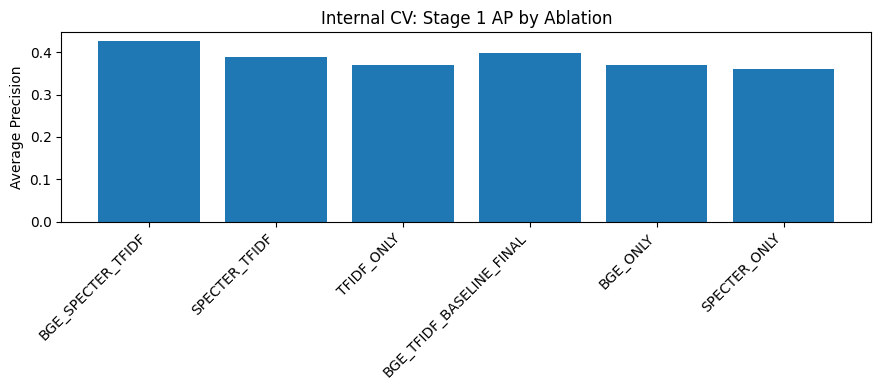

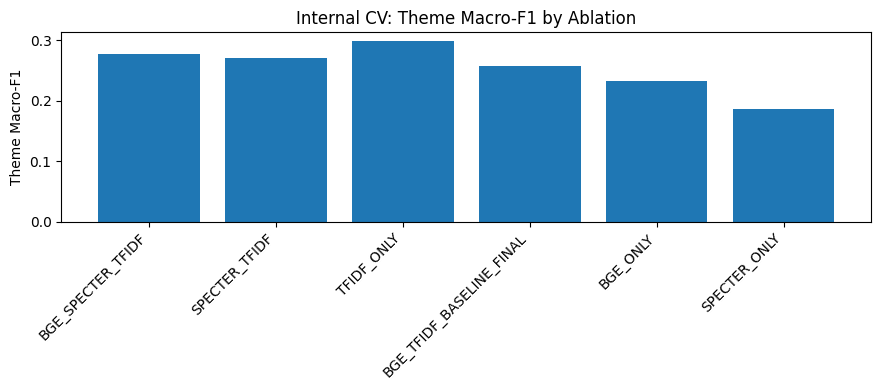

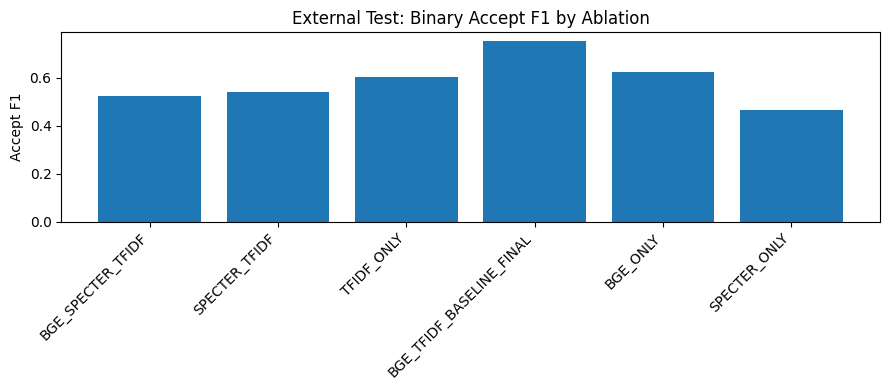

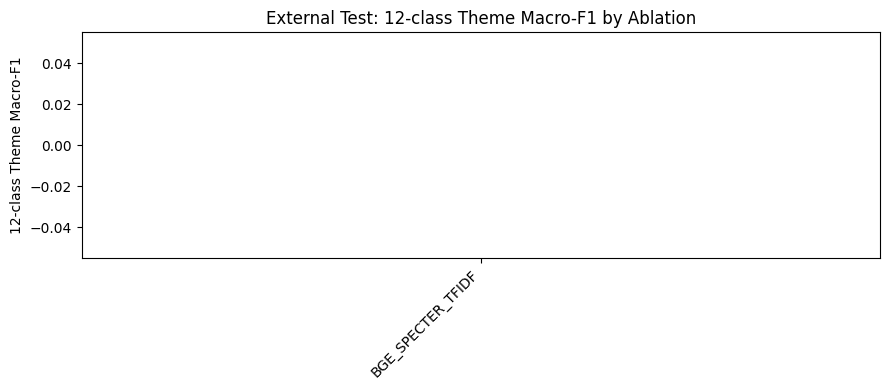

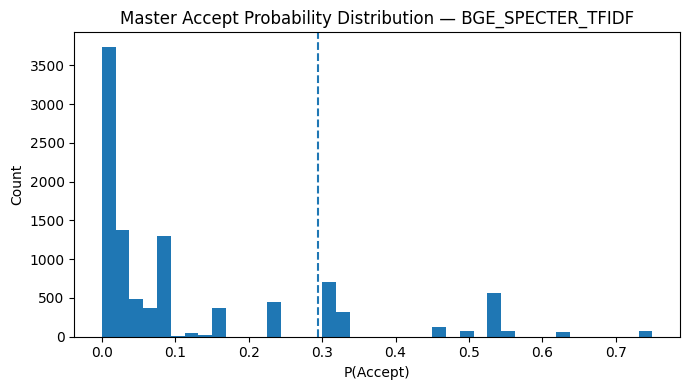

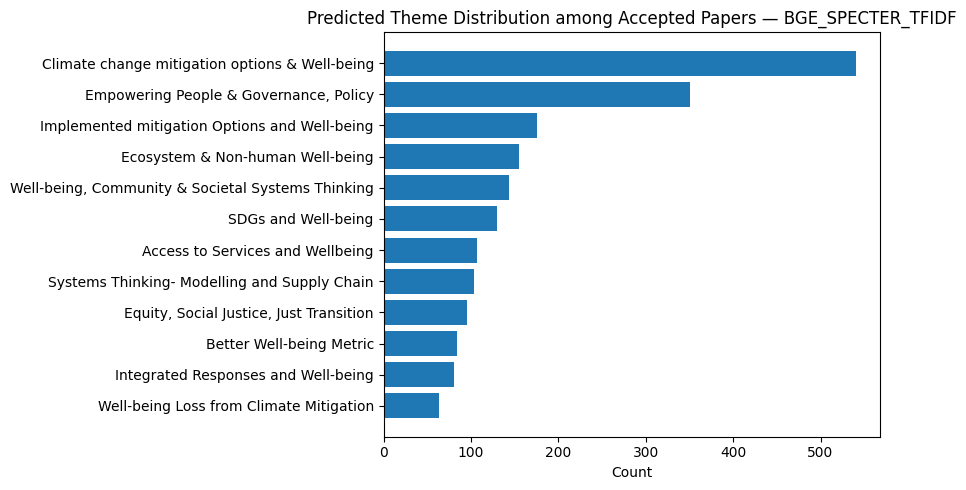

ZIP saved to: /kaggle/working/bge_specter_tfidf_external_test_monitor_outputs.zip


In [8]:
# ============================================================
# 8. Result tables, plots, and zip export
# ============================================================
theme_distribution = (
    out.loc[out["pred_decision"].eq("Accept"), "pred_theme"]
    .value_counts()
    .rename_axis("theme")
    .reset_index(name="predicted_count")
)
theme_distribution["share_of_accepted"] = theme_distribution["predicted_count"] / max(1, int(out["pred_decision"].eq("Accept").sum()))
theme_distribution.to_csv(OUTPUT_DIR / f"{final_prefix}_master_theme_distribution.csv", index=False)

audit_summary = {
    "final_experiment": FINAL_EXPERIMENT_NAME,
    "excluded_models": ["ClimateBERT", "DeBERTa"],
    "external_test_policy": "Audit-only held-out monitor; not used for training or CV threshold tuning.",
    "n_training_rows": int(len(train_df)),
    "n_master_rows": int(len(master_df)),
    "n_external_test_rows": int(len(test_df)) if HAS_EXTERNAL_TEST else 0,
    "train_accept_rate": float(train_accept_rate),
    "n_themes": int(N_THEMES),
    "final_stage1_internal_metrics": final_stage1["metrics"],
    "final_stage2_internal_metrics": final_stage2["metrics"] if final_stage2 is not None else {},
    "final_master_accept_count": int(master_accept_final.sum()),
    "final_master_accept_rate": float(master_accept_final.mean()),
    "ablation_results_file": str(ablation_csv),
    "final_master_file": str(output_xlsx),
}
if HAS_EXTERNAL_TEST and final_result.get("external_audit") is not None:
    audit_summary["final_external_test_audit"] = final_result["external_audit"]

with open(OUTPUT_DIR / "run_summary_with_external_test.json", "w") as f:
    json.dump(to_py(audit_summary), f, indent=2)

print(json.dumps(to_py(audit_summary), indent=2))
print("\nTheme distribution among predicted accepted master papers:")
display(theme_distribution)

# Plots
plt.figure(figsize=(9, 4))
plot_df = ablation_df[ablation_df["status"].eq("completed")].copy()
plt.bar(plot_df["experiment"], plot_df["stage1_AP"])
plt.xticks(rotation=45, ha="right")
plt.title("Internal CV: Stage 1 AP by Ablation")
plt.ylabel("Average Precision")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "internal_stage1_ap_by_ablation.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(plot_df["experiment"], plot_df["stage2_theme_macro_f1"])
plt.xticks(rotation=45, ha="right")
plt.title("Internal CV: Theme Macro-F1 by Ablation")
plt.ylabel("Theme Macro-F1")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "internal_theme_macro_f1_by_ablation.png", dpi=200)
plt.show()

if HAS_EXTERNAL_TEST:
    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["experiment"], plot_df["external_binary_accept_f1"])
    plt.xticks(rotation=45, ha="right")
    plt.title("External Test: Binary Accept F1 by Ablation")
    plt.ylabel("Accept F1")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "external_binary_accept_f1_by_ablation.png", dpi=200)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["experiment"], plot_df["external_theme_macro_f1_12class"])
    plt.xticks(rotation=45, ha="right")
    plt.title("External Test: 12-class Theme Macro-F1 by Ablation")
    plt.ylabel("12-class Theme Macro-F1")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "external_theme_macro_f1_by_ablation.png", dpi=200)
    plt.show()

plt.figure(figsize=(7, 4))
plt.hist(master_p_full, bins=40)
plt.axvline(final_threshold_used, linestyle="--")
plt.title(f"Master Accept Probability Distribution — {FINAL_EXPERIMENT_NAME}")
plt.xlabel("P(Accept)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{final_prefix}_master_accept_probability_histogram.png", dpi=200)
plt.show()

if len(theme_distribution) > 0:
    plt.figure(figsize=(9, 5))
    tmp = theme_distribution.sort_values("predicted_count")
    plt.barh(tmp["theme"], tmp["predicted_count"])
    plt.title(f"Predicted Theme Distribution among Accepted Papers — {FINAL_EXPERIMENT_NAME}")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{final_prefix}_master_theme_distribution.png", dpi=200)
    plt.show()

zip_path = OUTPUT_DIR.parent / "bge_specter_tfidf_external_test_monitor_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(OUTPUT_DIR)))
print("ZIP saved to:", zip_path)

In [9]:
# ============================================================
# 9. Auto-generate dissertation-ready methodology/result note
# ============================================================
def safe_fmt(x, nd=4):
    try:
        if pd.isna(x): return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

completed = ablation_df[ablation_df["status"].eq("completed")].copy()
final_row = completed[completed["experiment"].eq(FINAL_EXPERIMENT_NAME)]

note_lines = []
note_lines.append("# BGE/SPECTER/TF-IDF External-Test Monitor Note")
note_lines.append("")
note_lines.append("## Methodological update")
note_lines.append("The original human-labelled dataset remains the training and internal cross-validation source. The newly human-verified `Test_sampled_data.xlsx` file is used only as an external audit sample from the master 10k dataset. This provides an independent reliability check for binary screening and accepted-only 12-class theme annotation without mixing the test sample into training.")
note_lines.append("")
note_lines.append("## Final best-balanced model")
note_lines.append(f"The final best-balanced model is **{FINAL_EXPERIMENT_NAME}**, combining BGE semantic embeddings, SPECTER scientific-document embeddings, and lexical TF-IDF features.")
note_lines.append("")
note_lines.append("## Ablation table")
table_cols = [c for c in [
    "experiment", "stage1_AP", "stage1_macro_f1", "stage1_accept_f1",
    "stage2_theme_macro_f1", "stage2_theme_weighted_f1",
    "master_accept_rate", "external_binary_AP", "external_binary_accept_f1",
    "external_theme_macro_f1_12class", "external_theme_weighted_f1", "external_monitor_score"
] if c in completed.columns]
note_lines.append(completed[table_cols].to_csv(index=False))

if len(final_row):
    r = final_row.iloc[0]
    note_lines.append("## Final model summary")
    note_lines.append(f"- Internal Stage 1 AP: **{safe_fmt(r.get('stage1_AP'))}**")
    note_lines.append(f"- Internal binary macro-F1: **{safe_fmt(r.get('stage1_macro_f1'))}**")
    note_lines.append(f"- Internal Accept F1: **{safe_fmt(r.get('stage1_accept_f1'))}**")
    note_lines.append(f"- Internal theme macro-F1: **{safe_fmt(r.get('stage2_theme_macro_f1'))}**")
    note_lines.append(f"- Master accept rate: **{safe_fmt(r.get('master_accept_rate'))}**")
    if HAS_EXTERNAL_TEST:
        note_lines.append(f"- External binary AP: **{safe_fmt(r.get('external_binary_AP'))}**")
        note_lines.append(f"- External Accept F1: **{safe_fmt(r.get('external_binary_accept_f1'))}**")
        note_lines.append(f"- External 12-class theme macro-F1: **{safe_fmt(r.get('external_theme_macro_f1_12class'))}**")
        note_lines.append(f"- External theme weighted-F1: **{safe_fmt(r.get('external_theme_weighted_f1'))}**")

note_lines.append("")
note_lines.append("## Interpretation")
note_lines.append("The external test monitor strengthens trust in the results by evaluating the trained model on a human-verified subset of the master dataset. Because the external sample is not used for fitting, it should be reported as an audit/monitoring result rather than a training validation score. If external results differ from internal CV, the discrepancy should be discussed as evidence of distribution shift between the original labelled set and the master-file sample.")

note_path = OUTPUT_DIR / "methodology_external_test_monitor_note.md"
note_path.write_text("\n".join(note_lines), encoding="utf-8")
print("Saved:", note_path)
print("\n".join(note_lines[:50]))

Saved: /kaggle/working/bge_specter_tfidf_external_test_monitor_outputs/methodology_external_test_monitor_note.md
# BGE/SPECTER/TF-IDF External-Test Monitor Note

## Methodological update
The original human-labelled dataset remains the training and internal cross-validation source. The newly human-verified `Test_sampled_data.xlsx` file is used only as an external audit sample from the master 10k dataset. This provides an independent reliability check for binary screening and accepted-only 12-class theme annotation without mixing the test sample into training.

## Final best-balanced model
The final best-balanced model is **BGE_SPECTER_TFIDF**, combining BGE semantic embeddings, SPECTER scientific-document embeddings, and lexical TF-IDF features.

## Ablation table
experiment,stage1_AP,stage1_macro_f1,stage1_accept_f1,stage2_theme_macro_f1,stage2_theme_weighted_f1,master_accept_rate,external_binary_AP,external_binary_accept_f1,external_theme_macro_f1_12class,external_theme_weighted_f1,ex

In [10]:
df=pd.read_csv("/kaggle/working/bge_specter_tfidf_external_test_monitor_outputs/ablation_results_with_external_test.csv")
df

,experiment,status,description,use_tfidf,embedding_models,embedding_dim,master_accept_count,master_accept_rate,accept_threshold,final_threshold,...,external_binary_confusion_matrix,external_theme_macro_f1_observed,external_theme_macro_f1_12class,external_theme_weighted_f1,external_theme_accuracy,external_theme_coverage,external_n_theme_test_rows,internal_selection_score,external_monitor_score,is_best_balanced_final_policy
0,BGE_SPECTER_TFIDF,completed,Best-balanced classical ablation model: BGE + ...,True,BAAI/bge-small-en-v1.5 + allenai/specter,1152,2029,0.199391,0.295,0.295,...,"[[379, 71], [7, 43]]",NaN,NaN,NaN,NaN,0,0,0.388446,0.273928,True
1,SPECTER_TFIDF,completed,"SPECTER + TF-IDF, usually strongest for binary...",True,allenai/specter,768,1312,0.128931,0.370,0.370,...,"[[414, 36], [18, 32]]",NaN,NaN,NaN,NaN,0,0,0.375609,0.254962,False
2,TFIDF_ONLY,completed,Lexical baseline using word/character TF-IDF o...,True,NaN,0,1124,0.110456,0.270,0.270,...,"[[426, 24], [18, 32]]",NaN,NaN,NaN,NaN,0,0,0.371606,0.282714,False
3,BGE_TFIDF_BASELINE_FINAL,completed,Original strong baseline: BGE + TF-IDF.,True,BAAI/bge-small-en-v1.5,384,1240,0.121855,0.330,0.330,...,"[[432, 18], [9, 41]]",NaN,NaN,NaN,NaN,0,0,0.370806,0.334955,False
4,BGE_ONLY,completed,BGE semantic embedding only.,False,BAAI/bge-small-en-v1.5,384,928,0.091195,0.275,0.275,...,"[[436, 14], [21, 29]]",NaN,NaN,NaN,NaN,0,0,0.331575,0.272464,False
5,SPECTER_ONLY,completed,SPECTER scientific-document embedding only.,False,allenai/specter,768,1898,0.186517,0.250,0.250,...,"[[378, 72], [13, 37]]",NaN,NaN,NaN,NaN,0,0,0.315220,0.200773,False


In [11]:
df1=pd.read_csv("/kaggle/working/bge_specter_tfidf_external_test_monitor_outputs/bge_specter_tfidf_master_annotated.csv")
df1

,ID_OLD,ID_New,Authors,Article Title,Publication Year,DOI,DOI Link,Abstract,_row_id,_id_for_match,...,final_experiment,pred_accept_probability,pred_accept_threshold,pred_decision,pred_theme_id,pred_theme,pred_theme_confidence,pred_theme_margin,review_bucket,review_priority_score
0,OA_3712,OA_3712,Cornelia Marietje Aneke Wattimena,NaN,2022,NaN,https://doi.org/10.32832/abdidos.v6i3.1321,The current use of forests should be directed ...,0,OA_3712,...,BGE_SPECTER_TFIDF,0.087336,0.295,Reject,NaN,NaN,NaN,NaN,low_priority,0.198084
1,WoS_1385,WoS_1385,"Weatherly, C; Doherty, FC","It ' s one thing after another, after another...",2025,10.1016/j.jrurstud.2025.103573,http://dx.doi.org/10.1016/j.jrurstud.2025.103573,Because of their closeness to and dependence o...,1,WoS_1385,...,BGE_SPECTER_TFIDF,0.037975,0.295,Reject,NaN,NaN,NaN,NaN,low_priority,0.185744
2,Scopus_5109,Scopus_5109,"L., Cameron, Laura; I.J., Mauro, Ian J.; K., S...","""A Return to and of the Land"": Indigenous Know...",2021,10.2993/0278-0771-41.3.368,NaN,While research on Indigenous knowledges on cli...,2,Scopus_5109,...,BGE_SPECTER_TFIDF,0.037975,0.295,Reject,NaN,NaN,NaN,NaN,low_priority,0.185744
3,Scopus_4859,Scopus_4859,"A.K., Menzies, Allyson K.; E., Bowlesa, E.; M....","""I see my culture starting to disappear"": Anis...",2022,10.1139/facets-2021-0066,NaN,Climate change disproportionately affects Indi...,3,Scopus_4859,...,BGE_SPECTER_TFIDF,0.540816,0.295,Accept,4.0,"Empowering People & Governance, Policy",0.307605,0.192855,accepted_theme_uncertain,0.857739
4,Scopus_1176,Scopus_1176,"A., Gellu, Ashok; D., Sharma, Damini; S., Rani...","""Impact of Climate Change on Coastal Cities: A...",2025,10.53555/jab.v11i2.211,NaN,This research article aims to establish the ef...,4,Scopus_1176,...,BGE_SPECTER_TFIDF,0.309091,0.295,Accept,11.0,"Well-being, Community & Societal Systems Thinking",0.135122,0.026526,high_priority_review,0.966800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10171,OA_4235,OA_4235,Сырбек П.Н.|Бимендиева Л.А.|Мурабилдаева Р.А.|...,ҚАЗАҚСТАН РЕСПУБЛИКАСЫНДАҒЫ АЗЫҚ-ТҮЛІК ЖҮЙЕСІН...,2024,NaN,https://doi.org/10.52260/2304-7216.2024.3(56).4,Food systems are at the heart of the 2030 Agen...,10171,OA_4235,...,BGE_SPECTER_TFIDF,0.020101,0.295,Reject,NaN,NaN,NaN,NaN,low_priority,0.181275
10172,OA_3078,OA_3078,А. Оразаліна|Г.А. Кадирова,СУЧАСНИЙ СТАН БАНКІВСЬКОЇ СИСТЕМИ РЕСПУБЛІКИ К...,2023,NaN,https://doi.org/10.32782/2222-5099.2023.9.21,"The Sustainable Development Goal ""Ending hunge...",10172,OA_3078,...,BGE_SPECTER_TFIDF,0.087336,0.295,Reject,NaN,NaN,NaN,NaN,low_priority,0.198084
10173,OA_4940,OA_4940,Samvel AVETISYAN,Պարենային անվտանգության ոլորտում ԵԱՏՄ երկրների...,2024,NaN,https://doi.org/10.52174/2579-2989_2024.1-60,"At present, the world is very concerned. This ...",10173,OA_4940,...,BGE_SPECTER_TFIDF,0.020101,0.295,Reject,NaN,NaN,NaN,NaN,low_priority,0.181275
10174,OA_4085,OA_4085,د المعتصم بالله البحراوي د رامي السعدني,آثار تغير المناخ على الاقتصاد الأزرق في مصر,2023,NaN,https://doi.org/10.21608/mjle.2023.314883,"The term ""blue economy"" was widely adopted as ...",10174,OA_4085,...,BGE_SPECTER_TFIDF,0.087336,0.295,Reject,NaN,NaN,NaN,NaN,low_priority,0.198084


In [12]:
df2=pd.read_csv("/kaggle/working/bge_specter_tfidf_external_test_monitor_outputs/bge_specter_tfidf_master_theme_distribution.csv")
df2

,theme,predicted_count,share_of_accepted
0,Climate change mitigation options & Well-being,541,0.266634
1,"Empowering People & Governance, Policy",351,0.172992
2,Implemented mitigation Options and Well-being,175,0.086249
3,Ecosystem & Non-human Well-being,155,0.076392
4,"Well-being, Community & Societal Systems Thinking",143,0.070478
5,SDGs and Well-being,130,0.064071
6,Access to Services and Wellbeing,107,0.052735
7,Systems Thinking- Modelling and Supply Chain,104,0.051257
8,"Equity, Social Justice, Just Transition",95,0.046821
9,Better Well-being Metric,84,0.041400
